In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, roc_auc_score, classification_report, 
                             confusion_matrix, roc_curve, precision_score, 
                             recall_score, accuracy_score, precision_recall_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
train_data = pd.read_csv('train_data.txt', sep='\t')
test_data = pd.read_csv('test_data.txt', sep='\t')

In [5]:
# Top 10 LASSO Features
top_10_features = [
    'e_feed_flow_valve', 'composition_of_c_purge', 'purge_rate', 
    'a_feed_flow_valve', 'stripper_liquid_product_flow_valve', 
    'composition_of_g_purge', 'separator_pressure', 
    'condenser_cooling_water_outlet_temp', 'purge_valve', 'stripper_level'
]

In [6]:
normal_train_data = train_data[train_data['fault_label'] == 0].copy()

In [7]:
# Scale on normal data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(normal_train_data[top_10_features])

In [8]:
X_test_scaled = scaler.transform(test_data[top_10_features])
y_test_true = test_data['fault_label'].values

In [9]:
seq_length = 10

def create_sequences(data, labels, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i:(i + seq_length)])
        if labels is not None:
            ys.append(labels[i + seq_length - 1]) 
    return np.array(xs), np.array(ys)

In [10]:
X_train_seq, _ = create_sequences(X_train_scaled, None, seq_length)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_true, seq_length)

In [11]:
# Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)

In [12]:
train_loader = DataLoader(TensorDataset(X_train_tensor, X_train_tensor), batch_size=256, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, X_test_tensor), batch_size=256, shuffle=False)

In [13]:
class Tran_LSTM_Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_heads):
        super(Tran_LSTM_Autoencoder, self).__init__()
        
        # LSTM for temporal sequences
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, batch_first=True)
        
        # Transformer for multi-sensor attention
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads, batch_first=True, dim_feedforward=hidden_dim*2, dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        
        # Decoder back to original sensors
        self.decoder = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        transformer_out = self.transformer(lstm_out)
        return self.decoder(transformer_out)

model = Tran_LSTM_Autoencoder(input_dim=len(top_10_features), hidden_dim=32, num_heads=4).to(device)

In [14]:
criterion = nn.SmoothL1Loss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 15

In [15]:
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_x, _ in train_loader:
        batch_x = batch_x.to(device)
        
        optimizer.zero_grad()
        reconstructed = model(batch_x)
        loss = criterion(reconstructed, batch_x)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.6f}")

Epoch 1/15 | Loss: 0.018539
Epoch 2/15 | Loss: 0.000418
Epoch 3/15 | Loss: 0.000177
Epoch 4/15 | Loss: 0.000104
Epoch 5/15 | Loss: 0.000070
Epoch 6/15 | Loss: 0.000054
Epoch 7/15 | Loss: 0.000044
Epoch 8/15 | Loss: 0.000037
Epoch 9/15 | Loss: 0.000033
Epoch 10/15 | Loss: 0.000030
Epoch 11/15 | Loss: 0.000037
Epoch 12/15 | Loss: 0.000023
Epoch 13/15 | Loss: 0.000025
Epoch 14/15 | Loss: 0.000023
Epoch 15/15 | Loss: 0.000055


In [16]:
model.eval()
train_reconstruction_errors = []

with torch.no_grad():
    for batch_x, _ in train_loader:
        batch_x = batch_x.to(device)
        reconstructed = model(batch_x)
        error = torch.mean(torch.abs(reconstructed - batch_x), dim=(1,2)).cpu().numpy()
        train_reconstruction_errors.extend(error)

baseline_mean = np.mean(train_reconstruction_errors)
baseline_std = np.std(train_reconstruction_errors)

print(f"Baseline Mean: {baseline_mean:.5f}")
print(f"Baseline Std:  {baseline_std:.5f}")

Baseline Mean: 0.00324
Baseline Std:  0.00083


In [17]:
test_reconstruction_errors = []

with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        reconstructed = model(batch_x)
        error = torch.mean(torch.abs(reconstructed - batch_x), dim=(1,2)).cpu().numpy()
        test_reconstruction_errors.extend(error)

test_reconstruction_errors = np.array(test_reconstruction_errors)

In [18]:
def state_aware_adaptive_cusum(residuals, base_mean, base_std, dynamic_window=50, allowance_factor=0.5, sigma_multiplier=3):
    cusum_pos = np.zeros(len(residuals))
    alarms = np.zeros(len(residuals))
    
    rolling_window = [base_mean] * dynamic_window 
    
    current_mean = base_mean
    current_std = base_std
    
    for t in range(1, len(residuals)):
        control_limit = current_mean + (sigma_multiplier * current_std)
        allowance = allowance_factor * current_std
        
        cusum_pos[t] = max(0, cusum_pos[t-1] + residuals[t] - current_mean - allowance)
        
        # Check alarm
        if cusum_pos[t] > control_limit:
            alarms[t] = 1
            cusum_pos[t] = 0  
            
        else:
            alarms[t] = 0
            
            rolling_window.append(residuals[t])
            rolling_window.pop(0) 
            
            current_mean = np.mean(rolling_window)
            current_std = np.std(rolling_window)
            
            if current_std == 0: 
                current_std = 1e-6

    return cusum_pos, alarms

cusum_scores, y_pred_alarms = state_aware_adaptive_cusum(
    test_reconstruction_errors, 
    baseline_mean, 
    baseline_std, 
    dynamic_window=50,
    allowance_factor=0.1,  
    sigma_multiplier=2.5   
)

In [19]:
accuracy = accuracy_score(y_test_seq, y_pred_alarms)
precision = precision_score(y_test_seq, y_pred_alarms)
recall = recall_score(y_test_seq, y_pred_alarms)
f1 = f1_score(y_test_seq, y_pred_alarms)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f} ")

# 2. AUC 
roc_auc = roc_auc_score(y_test_seq, cusum_scores)

# Precision-Recall curve and PR-AUC
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test_seq, cusum_scores)
pr_auc = auc(recall_vals, precision_vals)

print(f"\nROC-AUC Score: {roc_auc:.4f}")
print(f"PR-AUC Score:  {pr_auc:.4f}")

print("\n classification")
print(classification_report(y_test_seq, y_pred_alarms, target_names=['Normal (0)', 'Faulty (1)']))

Accuracy:  0.3812
Precision: 0.9940
Recall:    0.3524
F1 Score:  0.5203 

ROC-AUC Score: 0.4097
PR-AUC Score:  0.9401

 classification
              precision    recall  f1-score   support

  Normal (0)       0.07      0.96      0.13    479991
  Faulty (1)       0.99      0.35      0.52   9599999

    accuracy                           0.38  10079990
   macro avg       0.53      0.66      0.32  10079990
weighted avg       0.95      0.38      0.50  10079990



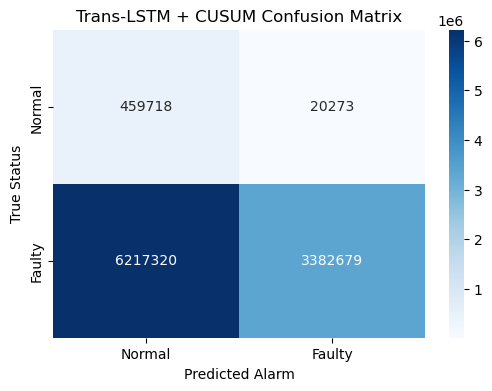

In [20]:
# Confusion Matrix
cm = confusion_matrix(y_test_seq, y_pred_alarms)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Faulty'], yticklabels=['Normal', 'Faulty'])
plt.title("Trans-LSTM + CUSUM Confusion Matrix")
plt.ylabel('True Status')
plt.xlabel('Predicted Alarm')
plt.show()

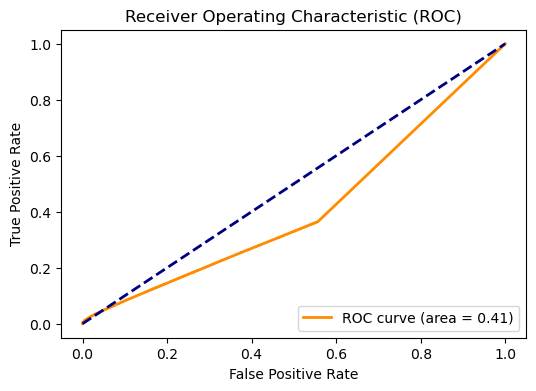

In [21]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test_seq, cusum_scores)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

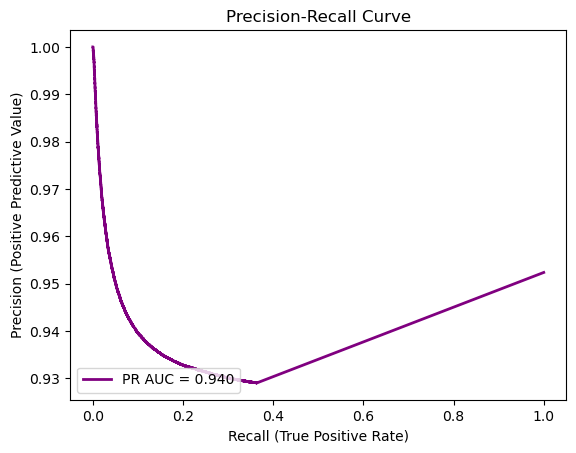

In [22]:
# Precision-Recall
plt.plot(recall_vals, precision_vals, color='purple', lw=2, label=f'PR AUC = {pr_auc:.3f}')
plt.xlabel('Recall (True Positive Rate)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()